<a href="https://colab.research.google.com/github/ml-crypto-debug/medical_triage_machine-learning-model/blob/main/fedmml_ed_triage_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/medical_triage/fedmml_ed_triage_dataset.csv")

In [22]:
print("Shape:", df.shape)
print("\nColumns and Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics (numerical):")
print(df.describe().T)

Shape: (87234, 28)

Columns and Types:
encounter_id          object
patient_id            object
site_id                int64
country               object
age                    int64
sex                   object
arrival_timestamp     object
chief_complaint       object
clinical_notes        object
systolic_bp          float64
diastolic_bp         float64
heart_rate           float64
respiratory_rate     float64
temperature          float64
spo2                 float64
pain_score           float64
wbc                  float64
hemoglobin           float64
platelet_count       float64
sodium               float64
potassium            float64
creatinine           float64
glucose              float64
troponin             float64
bnp                  float64
lactate              float64
inr                  float64
esi_level              int64
dtype: object

First 5 rows:
  encounter_id patient_id  site_id  country  age sex    arrival_timestamp  \
0   ENC1000001  PAT000001        1  Denmark

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Categorical analysis
print("Site distribution:")
print(df[['site_id', 'country']].value_counts())

print("\nSex distribution:")
print(df['sex'].value_counts(normalize=True) * 100)

print("\nESI Level distribution:")
print(df['esi_level'].value_counts().sort_index())
print(df['esi_level'].value_counts(normalize=True).sort_index() * 100)

print("\nTop 10 Chief Complaints:")
print(df['chief_complaint'].value_counts().head(10))

# Check data anomalies
anomalies = {
    'spo2 > 100': (df['spo2'] > 100).sum(),
    'wbc < 0': (df['wbc'] < 0).sum(),
    'platelet_count < 0': (df['platelet_count'] < 0).sum(),
    'creatinine < 0': (df['creatinine'] < 0).sum(),
    'troponin < 0': (df['troponin'] < 0).sum(),
    'bnp < 0': (df['bnp'] < 0).sum(),
    'lactate < 0': (df['lactate'] < 0).sum(),
}
print("\nData anomalies/negative values in non-negative physiological fields:")
print(anomalies)

Site distribution:
site_id  country
1        Denmark    18234
2        Denmark    15892
3        Turkey     14567
4        Turkey     13234
5        Latvia     12892
6        Latvia     12415
Name: count, dtype: int64

Sex distribution:
sex
F    51.176147
M    48.823853
Name: proportion, dtype: float64

ESI Level distribution:
esi_level
1      924
2    16789
3    41389
4    23199
5     4933
Name: count, dtype: int64
esi_level
1     1.059220
2    19.245936
3    47.445950
4    26.593989
5     5.654905
Name: proportion, dtype: float64

Top 10 Chief Complaints:
chief_complaint
Laceration requiring sutures    6934
Back pain                       6932
Vomiting                        6929
Moderate abdominal pain         6915
Headache severe                 6862
Fever                           6817
Minor injury                    3898
Mild abdominal discomfort       3893
Sprain                          3872
Rash                            3872
Name: count, dtype: int64

Data anomalies/negative

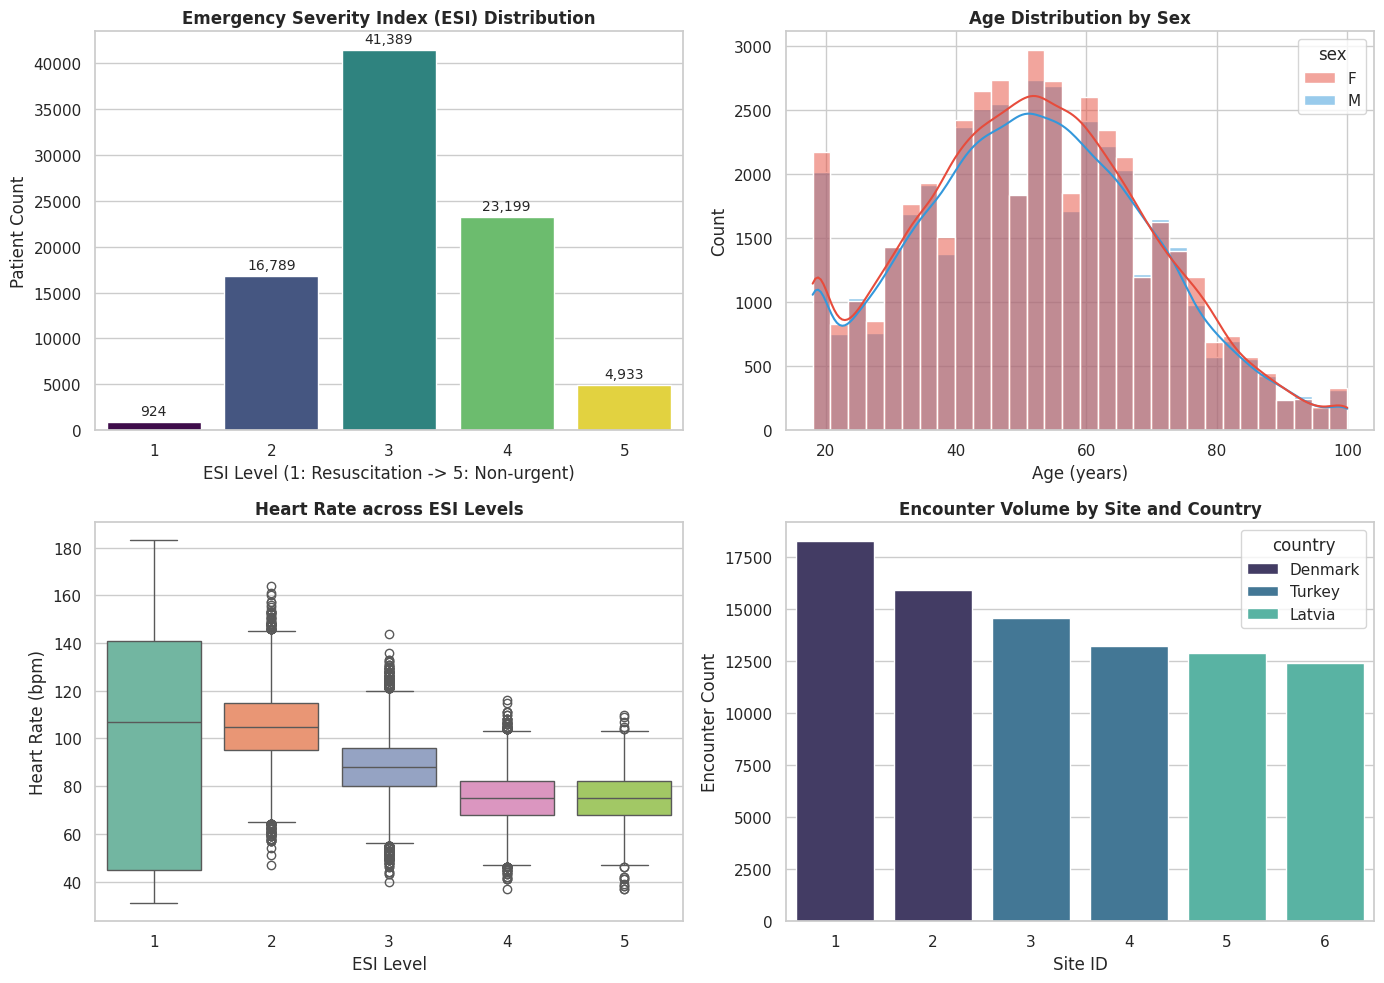

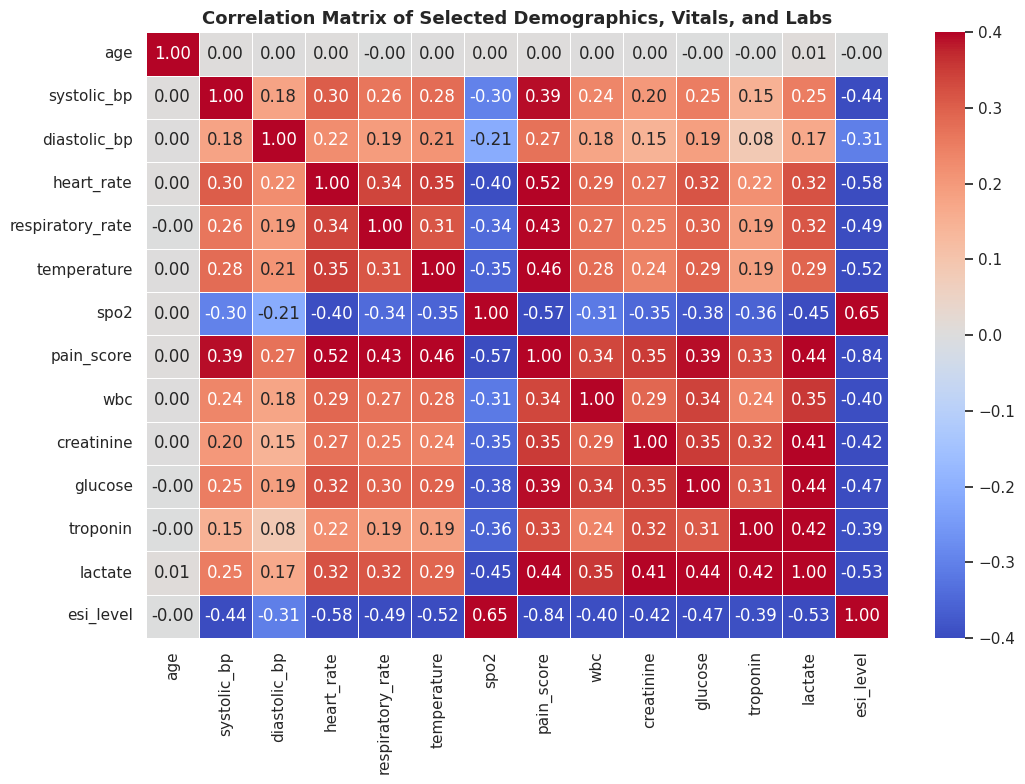

Plots displayed successfully.


In [24]:
# Generate visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ESI Level Distribution
sns.countplot(ax=axes[0, 0], data=df, x='esi_level', hue='esi_level', palette='viridis', legend=False)
axes[0, 0].set_title('Emergency Severity Index (ESI) Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('ESI Level (1: Resuscitation -> 5: Non-urgent)')
axes[0, 0].set_ylabel('Patient Count')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# 2. Age distribution by Sex
sns.histplot(ax=axes[0, 1], data=df, x='age', hue='sex', bins=30, kde=True, palette={'F': '#e74c3c', 'M': '#3498db'}, alpha=0.5)
axes[0, 1].set_title('Age Distribution by Sex', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Count')

# 3. Heart Rate vs ESI Level
sns.boxplot(ax=axes[1, 0], data=df, x='esi_level', y='heart_rate', hue='esi_level', palette='Set2', legend=False)
axes[1, 0].set_title('Heart Rate across ESI Levels', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('ESI Level')
axes[1, 0].set_ylabel('Heart Rate (bpm)')

# 4. Patient Volume by Country & Site
site_summary = df.groupby(['country', 'site_id']).size().reset_index(name='count')
sns.barplot(ax=axes[1, 1], data=site_summary, x='site_id', y='count', hue='country', dodge=False, palette='mako')
axes[1, 1].set_title('Encounter Volume by Site and Country', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Site ID')
axes[1, 1].set_ylabel('Encounter Count')

plt.tight_layout()
plt.show() # Display the first set of plots

# Second plot: Correlation heatmap of vitals & labs
vital_lab_cols = ['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
                  'temperature', 'spo2', 'pain_score', 'wbc', 'creatinine', 'glucose', 'troponin', 'lactate', 'esi_level']
corr = df[vital_lab_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.4, vmax=0.4, linewidths=0.5)
plt.title('Correlation Matrix of Selected Demographics, Vitals, and Labs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show() # Display the second plot

print("Plots displayed successfully.")

In [27]:
# ---------------------------------------------------------
# 1. Anomaly & Outlier Correction
# ---------------------------------------------------------
# Oxygen saturation cannot exceed 100%
df['spo2'] = df['spo2'].clip(upper=100.0)

# Replace negative values in strictly non-negative lab test results with NaN
lab_cols = ['wbc', 'platelet_count', 'creatinine', 'troponin', 'bnp', 'lactate', 'inr']
for col in lab_cols:
    df.loc[df[col] < 0, col] = np.nan


# ---------------------------------------------------------
# 2. Temporal Feature Extraction
# ---------------------------------------------------------
df['arrival_timestamp'] = pd.to_datetime(df['arrival_timestamp'])
df['arrival_hour'] = df['arrival_timestamp'].dt.hour
df['arrival_dayofweek'] = df['arrival_timestamp'].dt.dayofweek
df['is_weekend'] = df['arrival_dayofweek'].isin([5, 6]).astype(int)


# ---------------------------------------------------------
# 3. Missing Data Imputation & Feature Engineering
# ---------------------------------------------------------
# Vitals (5,492 missing): Impute using median grouped by ESI acuity level
vitals_cols = ['systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
               'temperature', 'spo2', 'pain_score']
for col in vitals_cols:
    df[col] = df.groupby('esi_level')[col].transform(lambda x: x.fillna(x.median()))

# Labs (26,603 missing): Order missingness carries clinical signal (e.g., non-severe patients don't get blood drawn).
# Preserve missingness as binary indicators before median imputation.
all_labs = ['wbc', 'hemoglobin', 'platelet_count', 'sodium', 'potassium',
            'creatinine', 'glucose', 'troponin', 'bnp', 'lactate', 'inr']

for col in all_labs:
    df[f'{col}_missing_flag'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

# Clinical Notes: Fill missing values with default token
df['clinical_notes'] = df['clinical_notes'].fillna('no notes available').str.strip()
df['chief_complaint'] = df['chief_complaint'].fillna('unknown').str.strip().str.lower()


# ---------------------------------------------------------
# 4. Categorical Encoding & Normalization
# ---------------------------------------------------------
df['sex_male'] = (df['sex'] == 'M').astype(int)

# One-hot encode 'country' column
df = pd.get_dummies(df, columns=['country'], prefix='country', drop_first=True)

# Cleaned dataset output
df_cleaned = df.drop(columns=['sex'])
df_cleaned.to_csv('fedmml_ed_triage_cleaned.csv', index=False)

KeyError: "None of [Index(['country'], dtype='object')] are in the [columns]"

In [26]:
# ---------------------------------------------------------
# 1. Feature Engineering
# ---------------------------------------------------------
# Clinical derived metrics
df['shock_index'] = df['heart_rate'] / (df['systolic_bp'] + 1e-5)
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

# Vital Sign Abnormality Flags
df['is_hypoxic'] = (df['spo2'] < 92.0).astype(int)
df['is_tachycardic'] = (df['heart_rate'] >= 100.0).astype(int)
df['is_febrile'] = (df['temperature'] >= 38.0).astype(int)
df['is_hypotensive'] = (df['systolic_bp'] < 90.0).astype(int)

# Approximate MEWS Score (0-4 scale)
df['mews_score'] = (
    df['is_hypoxic'] + df['is_tachycardic'] +
    df['is_febrile'] + df['is_hypotensive']
)

# Text Keyword Flags from Chief Complaint
df['complaint_chest_pain'] = df['chief_complaint'].str.contains('chest pain', na=False).astype(int)
df['complaint_abdominal'] = df['chief_complaint'].str.contains('abdominal', na=False).astype(int)
df['complaint_injury'] = df['chief_complaint'].str.contains('injury|laceration|sprain', na=False).astype(int)

# Total Lab Tests Ordered (Proxy for clinical suspicion/complexity)
lab_flags = [c for c in df.columns if c.endswith('_missing_flag')]
df['total_labs_ordered'] = len(lab_flags) - df[lab_flags].sum(axis=1)


# ---------------------------------------------------------
# 2. Feature Selection Strategy
# ---------------------------------------------------------
# Drop non-predictive identifiers and raw text
features_to_exclude = ['encounter_id', 'patient_id', 'arrival_timestamp',
                       'clinical_notes', 'chief_complaint', 'esi_level']

X = df.drop(columns=[c for c in features_to_exclude if c in df.columns])
y = df['esi_level']

# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Random Forest Feature Importance for Ranking
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 Most Important Features for ESI Prediction:")
print(feature_importances.head(15))

ValueError: could not convert string to float: 'F'